In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["svg.fonttype"] = "none"

In [3]:
cov = pd.read_csv("data/Degron_PolII_merged_cov_boxplot.csv")
pause = pd.read_csv("data/Degron_PolII_pausing_ratio_with_metatadata.csv")

In [4]:
condition_map = {"D8L4Y_0h": "0 h", "D8L4Y_90min": "1.5 h", "D8L4Y_8h": "8 h"}
cov = cov[
    [
        "chr",
        "start",
        "end",
        "bin",
        "gene_id",
        "hgnc_symbol",
        "coverage",
        "dataset",
        "condition",
        "target",
        "coverage.fold",
    ]
]
cov = cov.assign(condition=lambda x: x.condition.map(condition_map))
cov["region"] = pd.Categorical(cov["dataset"], ["TSS", "Gene Body", "TTS"])
cov["condition"] = pd.Categorical(cov["condition"], ["0 h", "1.5 h", "8 h"])
pause["condition"] = pause["condition"].map(condition_map)
pause["condition"] = pd.Categorical(pause["condition"], ["0 h", "1.5 h", "8 h"])

In [5]:
cov["length"] = (cov["start"] - cov["end"]).abs()
pause["length"] = pause["length"]

print("Min cov length:", cov["length"].min())
print("Min pause length:", pause["length"].min())

Min cov length: 1000
Min pause length: 1004


/var/folders/bk/jfxwkhls69b5qm00y25gv6200000gp/T/ipykernel_30753/608446583.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("region")["coverage.fold"]


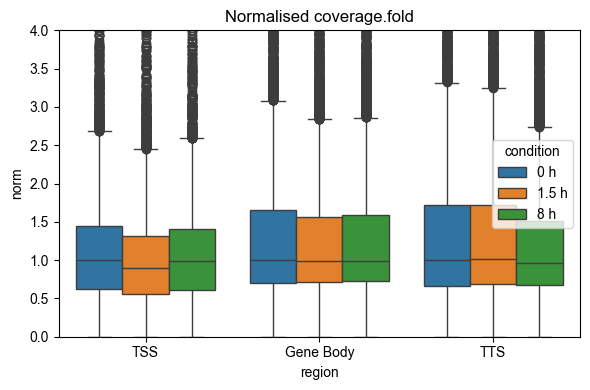

In [6]:
med = (
    cov[cov["condition"] == "0 h"]
    .groupby("region")["coverage.fold"]
    .median()
    .rename("median")
    .reset_index()
)

norm = cov.merge(med, on="region")
norm["norm"] = norm["coverage.fold"] / norm["median"]

plt.figure(figsize=(6, 4))
sns.boxplot(data=norm, x="region", y="norm", hue="condition")
plt.ylim(0, 4)
plt.title("Normalised coverage.fold")
plt.tight_layout()
plt.show()

In [7]:
zero = cov[cov["condition"] == "0 h"][["gene_id", "region", "coverage.fold"]]
short = cov[cov["condition"] == "1.5 h"][["gene_id", "region", "coverage.fold"]]
long = cov[cov["condition"] == "8 h"][["gene_id", "region", "coverage.fold"]]

print(len(zero) == len(short))
print(len(zero) == len(long))

True
True


In [8]:
short_fc = short.merge(zero, on=["gene_id", "region"], suffixes=("_1.5h", "_0h"))
short_fc["log2FC"] = np.log2(
    short_fc["coverage.fold_1.5h"] / short_fc["coverage.fold_0h"]
)
short_fc["condition"] = "1.5 h"

long_fc = long.merge(zero, on=["gene_id", "region"], suffixes=("_8h", "_0h"))
long_fc["log2FC"] = np.log2(long_fc["coverage.fold_8h"] / long_fc["coverage.fold_0h"])
long_fc["condition"] = "8 h"

all_fc = pd.concat([short_fc, long_fc])

/opt/homebrew/anaconda3/envs/spots-py310/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/homebrew/anaconda3/envs/spots-py310/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


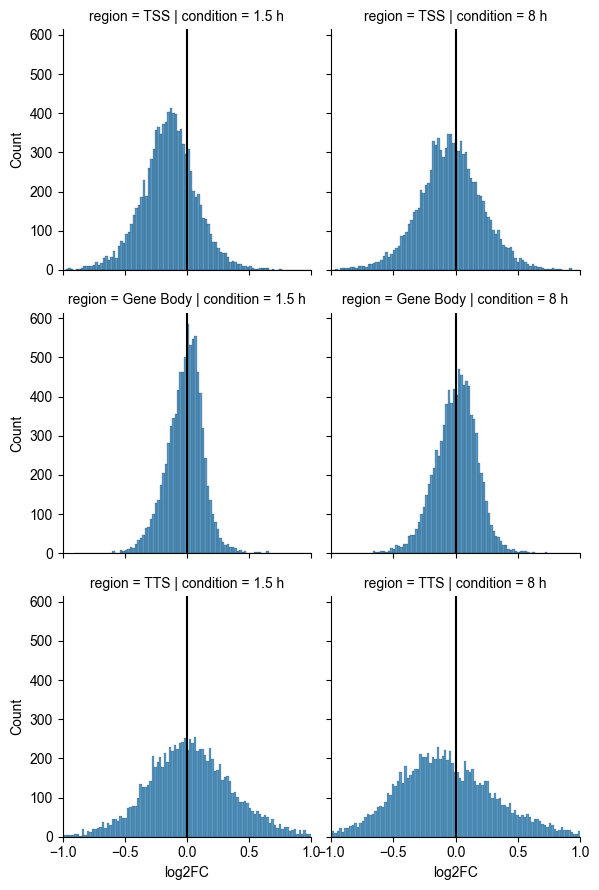

In [9]:
g = sns.FacetGrid(all_fc, col="condition", row="region", sharex=True, sharey=True)
g.map(sns.histplot, "log2FC", binwidth=0.02)
for ax in g.axes.flat:
    ax.axvline(0, color="black")
plt.xlim(-1, 1)
plt.show()

In [10]:
short_plot = short_fc[short_fc["region"] != "TTS"]
long_plot = long_fc[long_fc["region"] != "TTS"]

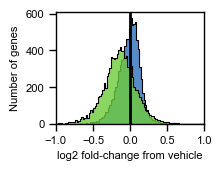

In [11]:
sns.set_context("paper")

f, a = plt.subplots(figsize=(3, 1.8))

pal = sns.color_palette(["xkcd:apple", "xkcd:medium blue", "grey"])

sns.histplot(
    data=short_plot,
    x="log2FC",
    hue="region",
    edgecolor="black",
    palette=pal,
    binwidth=0.02,
    alpha=0.8,
    element="step",
    legend=False,
)

a.set_box_aspect(0.75)
plt.xlim(-1, 1)
plt.axvline(0, color="black", linewidth=2)
plt.ylabel("Number of genes", fontsize=8)
plt.xlabel("log2 fold-change from vehicle", fontsize=8)
plt.tick_params(axis="both", labelsize=8)
plt.tight_layout()

plt.savefig("0_vs_90min_TSSgreen_GBblue.svg")

In [12]:
# Compute fold change of summed coverage - weights by expression level
for region in ["TSS", "Gene Body"]:
    subset = short_fc[short_fc["region"] == region]

    # Sum total coverage at each timepoint
    total_cov_0h = subset["coverage.fold_0h"].sum()
    total_cov_1_5h = subset["coverage.fold_1.5h"].sum()

    summed_fc = total_cov_1_5h / total_cov_0h

    print(f"\n{region}:")
    print(f"  Total coverage at 0h: {total_cov_0h:.1f}")
    print(f"  Total coverage at 1.5h: {total_cov_1_5h:.1f}")
    print(f"  Fold change (summed): {summed_fc:.4f}")


TSS:
  Total coverage at 0h: 53675.6
  Total coverage at 1.5h: 48809.1
  Fold change (summed): 0.9093

Gene Body:
  Total coverage at 0h: 13777.6
  Total coverage at 1.5h: 13238.2
  Fold change (summed): 0.9609
